# Shuttle Evaluation

In [12]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler


In [13]:
RANDOM_STATE = 1337

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "padme" / "src" / "main" / "resources" / "data"
OUT_DIR = DATA_DIR / "output/shuttle"

TRAIN_PATH = DATA_DIR / "input" / "shuttle_train.csv"
TEST_PATH = OUT_DIR / "shuttle_test.csv"

MODES = ["baseline", "padme", "random"]

NODES = 8
BASELINE_NODE = 0

RATIOS = [0.01, 0.02, 0.03, 0.04, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

DROP_COLS = ["__id", "label"]
LABEL_COL = "label"


In [14]:
def ratio_to_int(r: float) -> int:
    return int(round(r * 100))

def load_csv_any(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Not found: {path}")
    return pd.read_csv(path)

def load_test(train_csv: Path, test_csv: Path):
    if not test_csv.exists():
        raise FileNotFoundError(f"Required test set not found: {test_csv}. ")

    df_train = load_csv_any(train_csv)
    df_test = load_csv_any(test_csv)

    y_train = df_train[LABEL_COL].astype(int).to_numpy()
    X_train = df_train.drop(columns=[c for c in [LABEL_COL] + DROP_COLS if c in df_train.columns])

    y_test = df_test[LABEL_COL].astype(int).to_numpy()
    X_test = df_test.drop(columns=[c for c in [LABEL_COL] + DROP_COLS if c in df_test.columns])

    return X_train, y_train, X_test, y_test

X_train_full, y_train_full, X_test, y_test = load_test(TRAIN_PATH, TEST_PATH)

feature_cols = list(X_train_full.columns)

print("Train full:", X_train_full.shape, "Test:", X_test.shape, "Classes:", sorted(pd.Series(y_test).unique().tolist()))


Train full: (16000, 9) Test: (4000, 9) Classes: [1, 2, 3, 4, 5, 7]


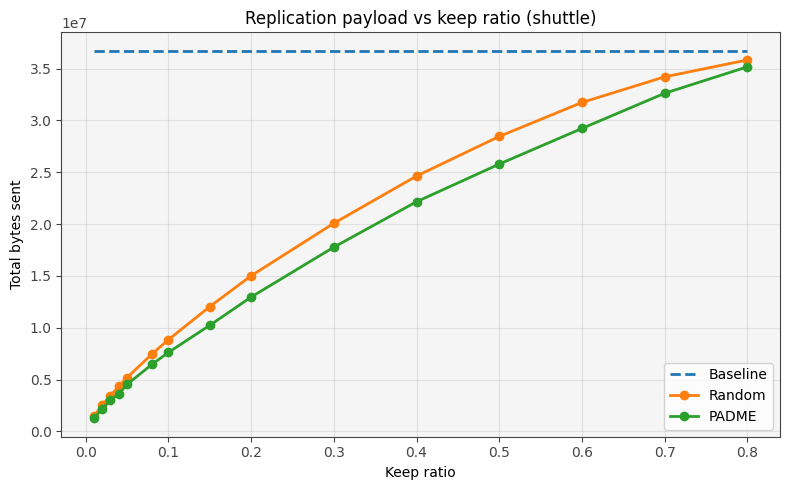

In [15]:
def load_metrics_json(path):
    p = Path(path)
    if not p.exists():
        return None
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)


def load_network_bytes_series(output_root: Path):
    output_root = Path(output_root)

    baseline_metrics = load_metrics_json(output_root / "baseline" / "metrics.json")
    baseline_bytes = None if baseline_metrics is None else baseline_metrics["totalBytesSent"]

    def load_mode_series(mode: str):
        mode_dir = output_root / mode
        if not mode_dir.exists():
            return [], []

        pairs = []
        for child in mode_dir.iterdir():
            if not child.is_dir():
                continue
            metrics = load_metrics_json(child / "metrics.json")
            if metrics is None:
                continue
            pairs.append((float(metrics["keepRatio"]), int(metrics["totalBytesSent"])))

        pairs.sort(key=lambda x: x[0])
        ratios = [x[0] for x in pairs]
        bytes_sent = [x[1] for x in pairs]
        return ratios, bytes_sent

    random_ratios, random_bytes = load_mode_series("random")
    padme_ratios, padme_bytes = load_mode_series("padme")

    return baseline_bytes, random_ratios, random_bytes, padme_ratios, padme_bytes


def plot_network_bytes_vs_keep_ratio(output_root, title=None):
    output_root = Path(output_root)

    baseline_bytes, random_ratios, random_bytes, padme_ratios, padme_bytes = load_network_bytes_series(output_root)

    plt.figure(figsize=(8, 5))

    if baseline_bytes is not None:
        x_for_line = sorted(set(random_ratios + padme_ratios))
        if not x_for_line:
            x_for_line = [0.0, 1.0]
        plt.plot(
            x_for_line,
            [baseline_bytes] * len(x_for_line),
            linestyle="--",
            linewidth=2,
            label="Baseline"
        )

    if random_ratios:
        plt.plot(
            random_ratios,
            random_bytes,
            marker="o",
            linewidth=2,
            label="Random"
        )

    if padme_ratios:
        plt.plot(
            padme_ratios,
            padme_bytes,
            marker="o",
            linewidth=2,
            label="PADME"
        )

    plt.xlabel("Keep ratio")
    plt.ylabel("Total bytes sent")
    plt.title(title or f"Replication payload vs keep ratio ({output_root.name})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_network_bytes_vs_keep_ratio(OUT_DIR)

In [16]:
def node_file(mode: str, ratio_int: int | None, node_idx: int) -> Path:
    if mode == "baseline":
        return OUT_DIR / "baseline" / f"baseline_node{node_idx}.csv"
    return OUT_DIR / mode / str(ratio_int) / f"{mode}_node{node_idx}.csv"

def load_node_dataset(mode: str, ratio: float | None, node_idx: int):
    r_int = None if ratio is None else ratio_to_int(ratio)
    p = node_file(mode, r_int, node_idx)

    df = load_csv_any(p)
    if LABEL_COL not in df.columns:
        raise ValueError(f"{p} does not have column '{LABEL_COL}'.")

    y = df[LABEL_COL].astype(int).to_numpy()
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
    X = X.reindex(columns=feature_cols, fill_value=0.0)

    return X, y, str(p)


In [17]:
stats_rows = []

for mode in ["baseline", "random", "padme"]:
    if mode == "baseline":
        ratios_to_check = [None]
    else:
        ratios_to_check = RATIOS

    for r in ratios_to_check:
        for i in range(NODES):
            Xn, yn, pn = load_node_dataset(mode, r, i)

            yn_series = pd.Series(yn)
            class_counts = yn_series.value_counts().sort_index().to_dict()
            total = int(len(yn_series))

            stats_rows.append({
                "mode": mode,
                "keep_ratio": 1.0 if r is None else float(r),
                "ratio_int": 100 if r is None else ratio_to_int(r),
                "node": i,
                "rows": total,
                "n_classes": int(yn_series.nunique()),
                "class_counts": class_counts,
                "file": str(pn)
            })

stats_df = pd.DataFrame(stats_rows).sort_values(
    ["mode", "keep_ratio", "node"]
).reset_index(drop=True)

stats_df


,mode,keep_ratio,ratio_int,node,rows,n_classes,class_counts,file
0,baseline,1.0,100,0,15976,7,"{1: 12548, 2: 16, 3: 44, 4: 2470, 5: 890, 6: 4...",C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
1,baseline,1.0,100,1,15970,7,"{1: 12540, 2: 16, 3: 44, 4: 2472, 5: 890, 6: 4...",C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
2,baseline,1.0,100,2,16000,7,"{1: 12567, 2: 16, 3: 44, 4: 2474, 5: 891, 6: 4...",C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
3,baseline,1.0,100,3,15988,7,"{1: 12558, 2: 16, 3: 44, 4: 2471, 5: 891, 6: 4...",C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
4,baseline,1.0,100,4,16000,7,"{1: 12567, 2: 16, 3: 44, 4: 2474, 5: 891, 6: 4...",C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
...,...,...,...,...,...,...,...,...
243,random,0.8,80,3,12800,7,"{1: 10073, 2: 9, 3: 36, 4: 1968, 5: 707, 6: 4,...",C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
244,random,0.8,80,4,12800,7,"{1: 10056, 2: 13, 3: 38, 4: 1964, 5: 721, 6: 4...",C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
245,random,0.8,80,5,12800,7,"{1: 10077, 2: 11, 3: 32, 4: 1975, 5: 698, 6: 3...",C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
246,random,0.8,80,6,12800,7,"{1: 10058, 2: 13, 3: 35, 4: 1962, 5: 726, 6: 2...",C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...


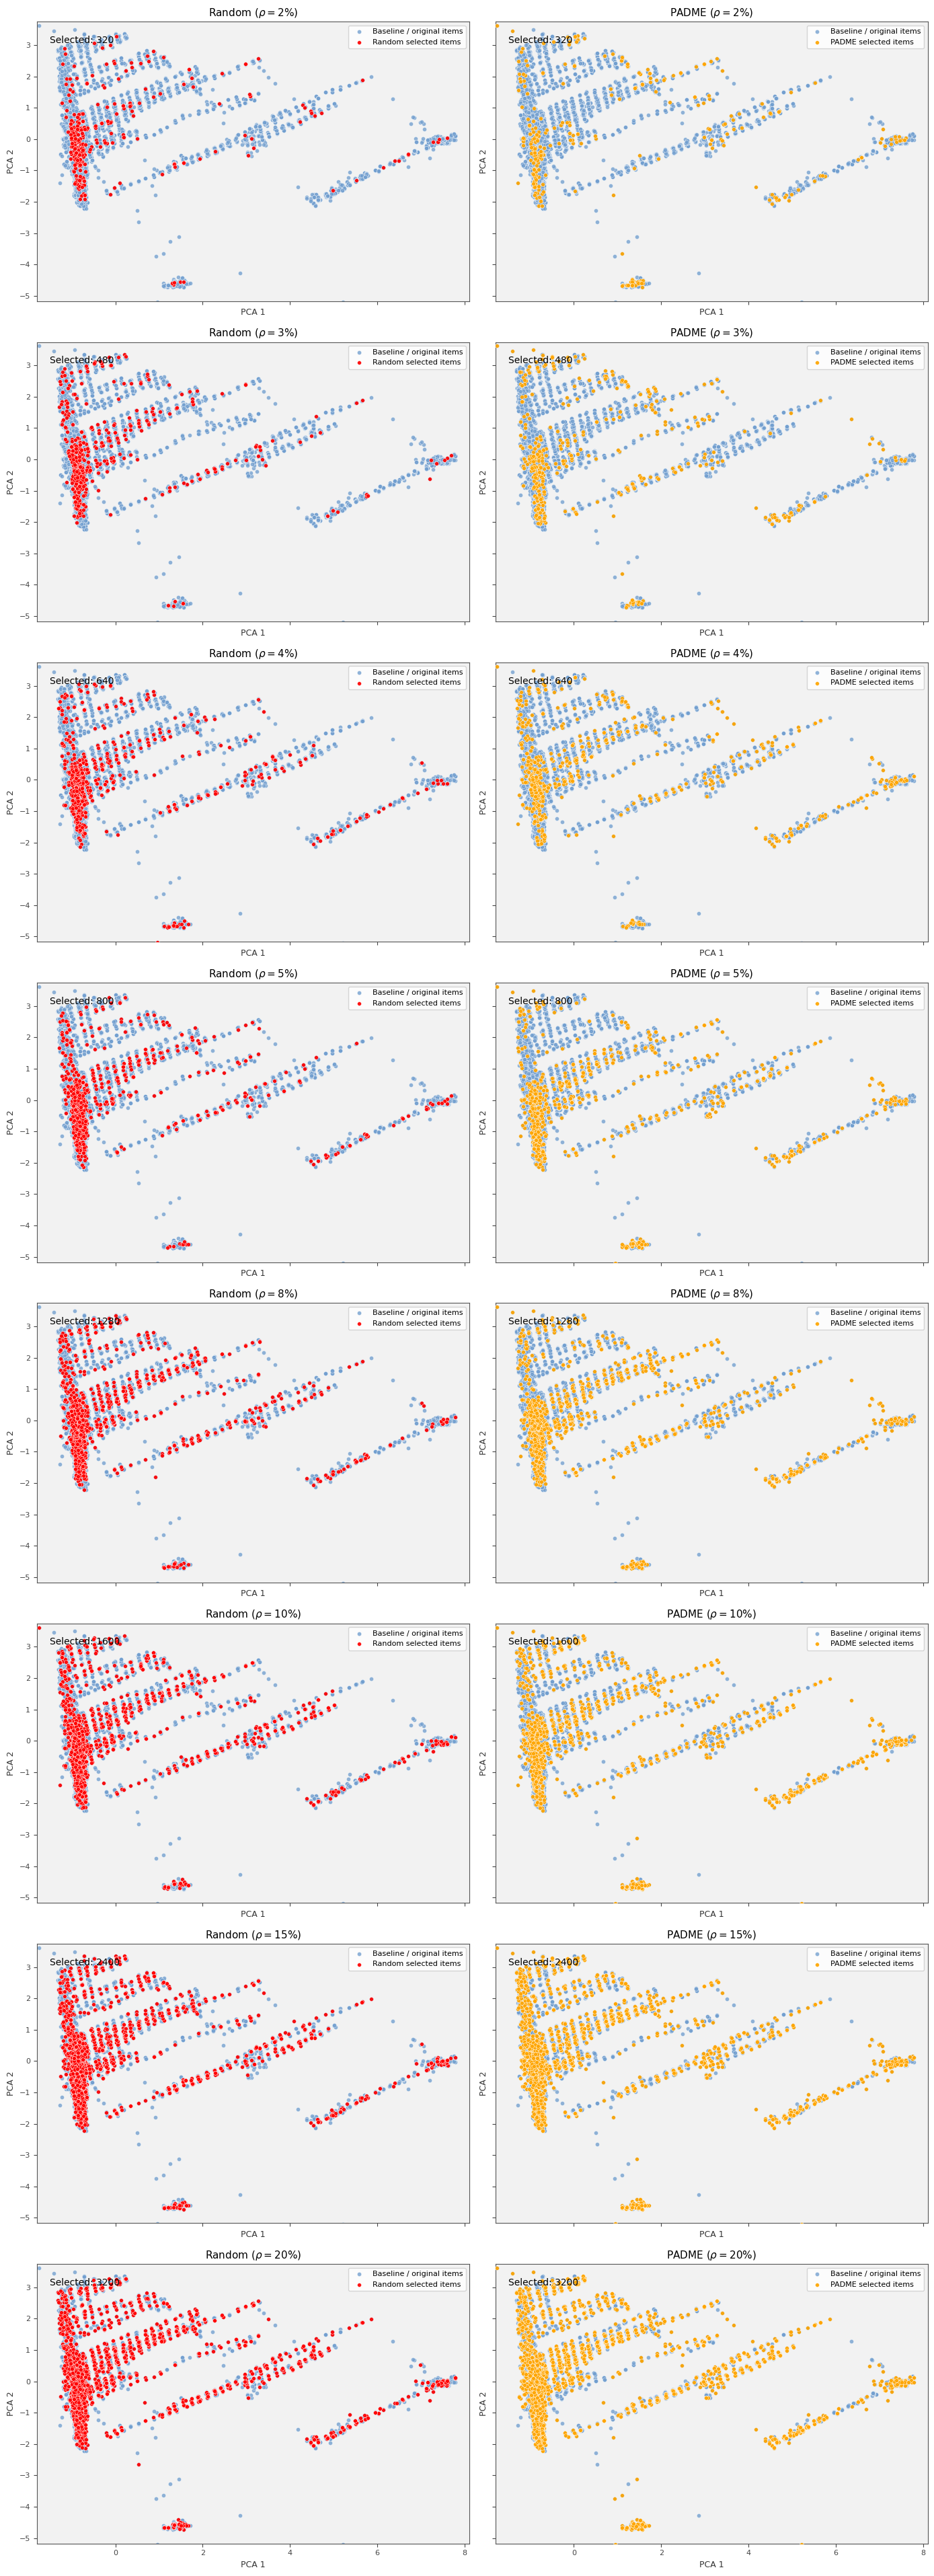

In [18]:
from matplotlib import rcParams

plt.rcdefaults()
plt.style.use("default")

rcParams["figure.facecolor"] = "white"
rcParams["axes.facecolor"] = "#f5f5f5"
rcParams["savefig.facecolor"] = "white"
rcParams["text.color"] = "black"
rcParams["axes.labelcolor"] = "black"
rcParams["axes.edgecolor"] = "#444444"
rcParams["xtick.color"] = "#444444"
rcParams["ytick.color"] = "#444444"
rcParams["legend.facecolor"] = "white"
rcParams["legend.edgecolor"] = "#cccccc"

baseline_path = OUT_DIR / "baseline" / "baseline_node0.csv"


def _load_geom_matrix(path):
    df = load_csv_any(path)
    X = df.drop(columns=[c for c in [LABEL_COL] + DROP_COLS if c in df.columns], errors="ignore")
    X = X.reindex(columns=feature_cols, fill_value=0.0)
    X = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return df, X


def _fit_pca_reference(X_base):
    Xb = X_base.to_numpy(dtype=float)
    scaler = StandardScaler()
    Xb_scaled = scaler.fit_transform(Xb)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    B = pca.fit_transform(Xb_scaled)
    return scaler, pca, B


def _project_subset(X, scaler, pca):
    Xs = X.to_numpy(dtype=float)
    Xs_scaled = scaler.transform(Xs)
    Z = pca.transform(Xs_scaled)
    return Z


def _robust_limits(*arrays, low=0.5, high=99.5, pad=0.06):
    x = np.concatenate([a[:, 0] for a in arrays if len(a) > 0])
    y = np.concatenate([a[:, 1] for a in arrays if len(a) > 0])
    x0, x1 = np.percentile(x, [low, high])
    y0, y1 = np.percentile(y, [low, high])
    dx = max(1e-9, x1 - x0)
    dy = max(1e-9, y1 - y0)
    return ((x0 - pad * dx, x1 + pad * dx), (y0 - pad * dy, y1 + pad * dy))


def _draw_panel(ax, B, S, title, selected_label, selected_color, xlim, ylim, base_s, selected_s):
    ax.set_facecolor("#f2f2f2")

    ax.scatter(
        B[:, 0], B[:, 1],
        s=base_s,
        alpha=0.78,
        color="#729fcf",
        edgecolors="white",
        linewidths=0.35,
        label="Baseline / original items",
        zorder=1
    )

    ax.scatter(
        S[:, 0], S[:, 1],
        s=selected_s,
        alpha=0.92,
        color=selected_color,
        edgecolors="white",
        linewidths=0.35,
        label=selected_label,
        zorder=3
    )

    ax.text(
        0.03, 0.95,
        f"Selected: {len(S)}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        color="black"
    )

    ax.set_title(title, fontsize=11, color="black")
    ax.set_xlabel("PCA 1", fontsize=9, color="#333333")
    ax.set_ylabel("PCA 2", fontsize=9, color="#333333")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=8, colors="#444444")
    ax.legend(frameon=True, loc="upper right", fontsize=8)

    for spine in ax.spines.values():
        spine.set_color("#555555")
        spine.set_linewidth(0.8)


def _available_ratios(mode_dir):
    ratios = []
    if not mode_dir.exists():
        return ratios
    for child in mode_dir.iterdir():
        if not child.is_dir():
            continue
        try:
            ratio_int = int(child.name)
            ratios.append(ratio_int / 100.0)
        except ValueError:
            pass
    return sorted(ratios)


def _node_file_for_ratio(mode, ratio):
    ratio_dir = OUT_DIR / mode / str(ratio_to_int(ratio))
    return ratio_dir / f"{mode}_node0.csv"


df_base, X_base = _load_geom_matrix(baseline_path)
scaler, pca, B = _fit_pca_reference(X_base)

random_ratios = set(_available_ratios(OUT_DIR / "random"))
padme_ratios = set(_available_ratios(OUT_DIR / "padme"))
target_ratios = [0.02, 0.03, 0.04, 0.05, 0.08, 0.10, 0.15, 0.20]
ratios = [r for r in target_ratios if r in random_ratios and r in padme_ratios]

proj_random = {}
proj_padme = {}
all_arrays = [B]

for ratio in ratios:
    random_path = _node_file_for_ratio("random", ratio)
    padme_path = _node_file_for_ratio("padme", ratio)

    if not random_path.exists() or not padme_path.exists():
        continue

    _, X_rand = _load_geom_matrix(random_path)
    _, X_padm = _load_geom_matrix(padme_path)

    R = _project_subset(X_rand, scaler, pca)
    P = _project_subset(X_padm, scaler, pca)

    proj_random[ratio] = R
    proj_padme[ratio] = P
    all_arrays.extend([R, P])

ratios = [r for r in ratios if r in proj_random and r in proj_padme]
xlim, ylim = _robust_limits(*all_arrays, low=0.5, high=99.5, pad=0.06)

n_rows = len(ratios)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4.8 * n_rows), sharex=True, sharey=True)
fig.patch.set_facecolor("white")

if n_rows == 1:
    axes = np.array([axes])

selected_s = 18
base_s = selected_s * 1.1

for i, ratio in enumerate(ratios):
    R = proj_random[ratio]
    P = proj_padme[ratio]
    pct = int(round(ratio * 100))

    _draw_panel(axes[i, 0], B, R, rf"Random ($\rho = {pct}\%$)", "Random selected items", "#FF0000", xlim, ylim, base_s, selected_s)
    _draw_panel(axes[i, 1], B, P, rf"PADME ($\rho = {pct}\%$)", "PADME selected items", "#FFA500", xlim, ylim, base_s, selected_s)

plt.tight_layout()
plt.show()

In [19]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )
}


In [20]:
def eval_metrics(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    macro_f1 = f1_score(y_test, pred, average="macro")
    bal_acc = balanced_accuracy_score(y_test, pred)

    return macro_f1, bal_acc

rows = []

for model_name, model in models.items():
    Xb, yb, pb = load_node_dataset("baseline", None, BASELINE_NODE)
    base_macro_f1, base_bal_acc = eval_metrics(model, Xb, yb, X_test, y_test)

    rows.append({
        "model": model_name,
        "mode": "baseline",
        "keep_ratio": 1.0,
        "ratio_int": 100,
        "node": BASELINE_NODE,
        "macro_f1": base_macro_f1,
        "balanced_accuracy": base_bal_acc,
        "macro_f1_mean": base_macro_f1,
        "macro_f1_std": 0.0,
        "balanced_accuracy_mean": base_bal_acc,
        "balanced_accuracy_std": 0.0
    })

    for mode in ["random", "padme"]:
        for r in RATIOS:
            f1_scores = []
            bal_acc_scores = []

            for i in range(NODES):
                Xn, yn, pn = load_node_dataset(mode, r, i)
                macro_f1, bal_acc = eval_metrics(model, Xn, yn, X_test, y_test)

                f1_scores.append(macro_f1)
                bal_acc_scores.append(bal_acc)

                rows.append({
                    "model": model_name,
                    "mode": mode,
                    "keep_ratio": r,
                    "ratio_int": ratio_to_int(r),
                    "node": i,
                    "macro_f1": macro_f1,
                    "balanced_accuracy": bal_acc,
                    "file": pn
                })

            rows.append({
                "model": model_name,
                "mode": mode,
                "keep_ratio": r,
                "ratio_int": ratio_to_int(r),
                "node": "mean",
                "macro_f1": float(np.mean(f1_scores)),
                "balanced_accuracy": float(np.mean(bal_acc_scores)),
                "macro_f1_mean": float(np.mean(f1_scores)),
                "macro_f1_std": float(np.std(f1_scores, ddof=1)) if len(f1_scores) > 1 else 0.0,
                "balanced_accuracy_mean": float(np.mean(bal_acc_scores)),
                "balanced_accuracy_std": float(np.std(bal_acc_scores, ddof=1)) if len(bal_acc_scores) > 1 else 0.0
            })

results = pd.DataFrame(rows)

results[(results["node"] == "mean") | (results["mode"] == "baseline")].sort_values(["model", "mode", "keep_ratio"])


SyntaxError: invalid syntax (2425934844.py, line 33)

In [ ]:
metric_mean = (
    results[
        results["node"].apply(lambda x: isinstance(x, (int, np.integer)))
    ][["model", "mode", "keep_ratio", "macro_f1", "balanced_accuracy"]]
    .groupby(["model", "mode", "keep_ratio"], as_index=False)
    .mean()
    .sort_values(["model", "mode", "keep_ratio"])
    .reset_index(drop=True)
)

for model in metric_mean["model"].unique():
    print(f"\n=== {model} ===")
    sub_model = metric_mean[metric_mean["model"] == model]

    for mode in sub_model["mode"].unique():
        print(f"\n-- {mode} --")
        sub_mode = sub_model[sub_model["mode"] == mode]

        for _, r in sub_mode.iterrows():
            print(
                f"keep_ratio={r['keep_ratio']:.2f} | "
                f"macro_f1={r['macro_f1']:.4f} | "
                f"balanced_accuracy={r['balanced_accuracy']:.4f}"
            )


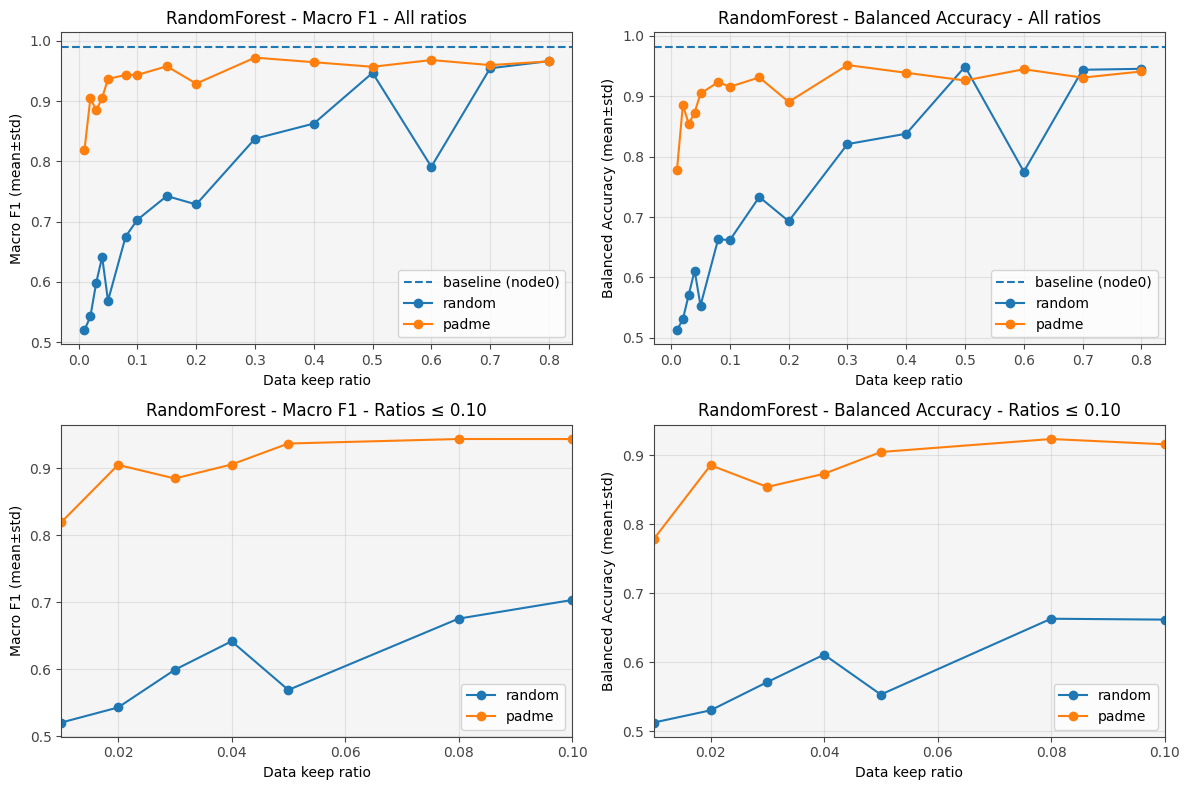

In [21]:
for model_name in models.keys():
    sub_mean = results[(results["model"] == model_name) & (results["node"] == "mean")].copy()
    base_row = results[(results["model"] == model_name) & (results["mode"] == "baseline")].iloc[0]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

    metrics = [
        ("macro_f1", "Macro F1"),
        ("balanced_accuracy", "Balanced Accuracy"),
    ]

    for col_idx, (metric_key, metric_label) in enumerate(metrics):
        ax = axes[0, col_idx]
        base = base_row[f"{metric_key}_mean"]
        ax.axhline(base, linestyle="--", label=f"baseline (node{BASELINE_NODE})")

        for mode in ["random", "padme"]:
            s = sub_mean[sub_mean["mode"] == mode].sort_values("keep_ratio")
            ax.errorbar(
                s["keep_ratio"],
                s[f"{metric_key}_mean"],
                # yerr=s[f"{metric_key}_std"],
                marker="o",
                capsize=3,
                label=mode
            )

        ax.set_xlabel("Data keep ratio")
        ax.set_ylabel(f"{metric_label} (mean±std)")
        ax.set_title(f"{model_name} - {metric_label} - All ratios")
        ax.legend()
        ax.grid(True, alpha=0.3)

        ax = axes[1, col_idx]
        sub_low = sub_mean[(sub_mean["mode"].isin(["random", "padme"])) & (sub_mean["keep_ratio"] <= 0.10)].copy()

        for mode in ["random", "padme"]:
            s = sub_low[sub_low["mode"] == mode].sort_values("keep_ratio")
            ax.errorbar(
                s["keep_ratio"],
                s[f"{metric_key}_mean"],
                # yerr=s[f"{metric_key}_std"],
                marker="o",
                capsize=3,
                label=mode
            )

        ax.set_xlim(sub_low["keep_ratio"].min(), 0.10)
        ax.set_xlabel("Data keep ratio")
        ax.set_ylabel(f"{metric_label} (mean±std)")
        ax.set_title(f"{model_name} - {metric_label} - Ratios ≤ 0.10")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()